# 01 — สำรวจ point cloud ของห้อง PFAL (SIS KU)

**เป้าหมาย (L1 Geometry twin, ขั้นแรก)**: ทำความรู้จักไฟล์ `SIS PFAL.ply` — จำนวนจุด, ระบบพิกัด, ขนาดคร่าวๆ, การกระจายตัวตามความสูง และดูภาพ 3 มิติแบบหมุนได้

ข้อมูลดิบ: สแกนด้วย LiDAR มือถือ, ASCII PLY, ต่อจุดมี ตำแหน่ง (x,y,z) / เวกเตอร์ตั้งฉาก (nx,ny,nz) / สี (RGB)
ระบบพิกัดของสแกน: หน่วยเมตร, **แกน Y ชี้ขึ้น** (Notebook 02 จะแปลงเป็น Z-up และจัดให้ผนังขนานแกน)

> รูปทุกรูปใช้ป้ายภาษาอังกฤษเพื่อนำไปใช้ในบทความได้โดยตรง (บันทึกใน `figures/`)

In [1]:
import sys, warnings
from pathlib import Path
warnings.filterwarnings("ignore")
ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import plotly.io as pio
from pfal_twin import io, geometry as G, viz, layout, thingsboard as tb, hydraulics as H, schematic as S
pio.renderers.default = "vscode+notebook"   # works in VS Code and JupyterLab
FIG = ROOT / "figures"; FIG.mkdir(exist_ok=True)
print("project root:", ROOT)

project root: /Users/gasza/Documents/Job/SIS KU/Task/Rong_Pralong/PFAL


## 1. โหลดไฟล์ (ครั้งแรก ~1 วินาที แล้ว cache เป็น `data/processed/raw.npz`)

In [2]:
pc = io.load_ply()
xyz, normals, rgb = pc["xyz"], pc["normals"], pc["rgb"]
print(f"points: {len(xyz):,}")
print("PLY path:", io.PLY_PATH)

points: 1,020,300
PLY path: /Users/gasza/Documents/Job/SIS KU/Task/Rong_Pralong/PFAL/data/raw/pointcloud/SIS PFAL.ply


## 2. สถิติพื้นฐาน — bounding box และขนาดตามแกน (ยังเป็นพิกัดสแกน)

In [3]:
stats = pd.DataFrame({
    "min": xyz.min(0), "p1": np.percentile(xyz, 1, axis=0), "median": np.median(xyz, axis=0),
    "p99": np.percentile(xyz, 99, axis=0), "max": xyz.max(0),
}, index=["x", "y (up)", "z"])
stats["extent (max-min)"] = stats["max"] - stats["min"]
stats["extent (p99-p1)"] = stats["p99"] - stats["p1"]
stats.round(3)

,min,p1,median,p99,max,extent (max-min),extent (p99-p1)
x,-3.254,-2.678,-1.175,0.452,2.417,5.671,3.130
y (up),-1.761,-1.470,-0.230,1.161,1.519,3.280,2.630
z,-6.498,-6.133,-2.409,1.032,2.830,9.328,7.165


`extent (p99-p1)` ตัดจุดหลงที่สแกนทะลุประตูออกไปแล้ว → ห้องกว้าง ~3.2 ม. ยาว ~7.2 ม. สูง ~2.6 ม.
ค่า `max-min` ที่ใหญ่กว่ามากในแกน z คือจุดนอกห้อง (จะ crop ทิ้งใน Notebook 02)

## 3. การกระจายตัวตามความสูง — ใช้เฉพาะจุดที่หันขึ้น/ลง (|ny| > 0.9) เพื่อให้เห็นพื้น, ชั้นปลูก, เพดาน เป็น peak

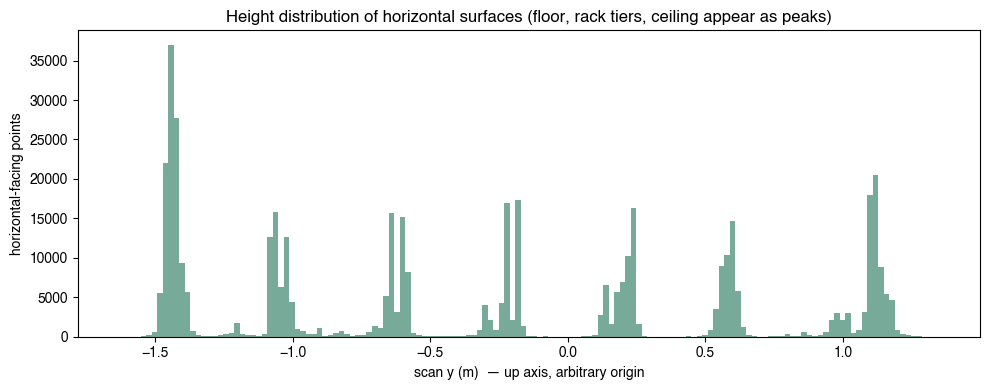

In [4]:
horiz = np.abs(normals[:, 1]) > 0.9
h = xyz[horiz, 1]
edges = np.arange(h.min(), h.max() + 0.02, 0.02)
fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(h, bins=edges, color="#7a9")
ax.set_xlabel("scan y (m)  — up axis, arbitrary origin"); ax.set_ylabel("horizontal-facing points")
ax.set_title("Height distribution of horizontal surfaces (floor, rack tiers, ceiling appear as peaks)")
fig.tight_layout(); fig.savefig(FIG / "01_height_histogram.png", dpi=150)

เห็น peak ของพื้น 1 อัน, ชั้นปลูก 5 อัน (ห่างกัน ~0.42 ม.) และเพดาน — ตรงกับชั้นปลูก 5 ชั้นในห้องจริง

## 4. มุมมอง 2 มิติ: plan view (มุมบน) / side / front — สีจริงจากกล้อง

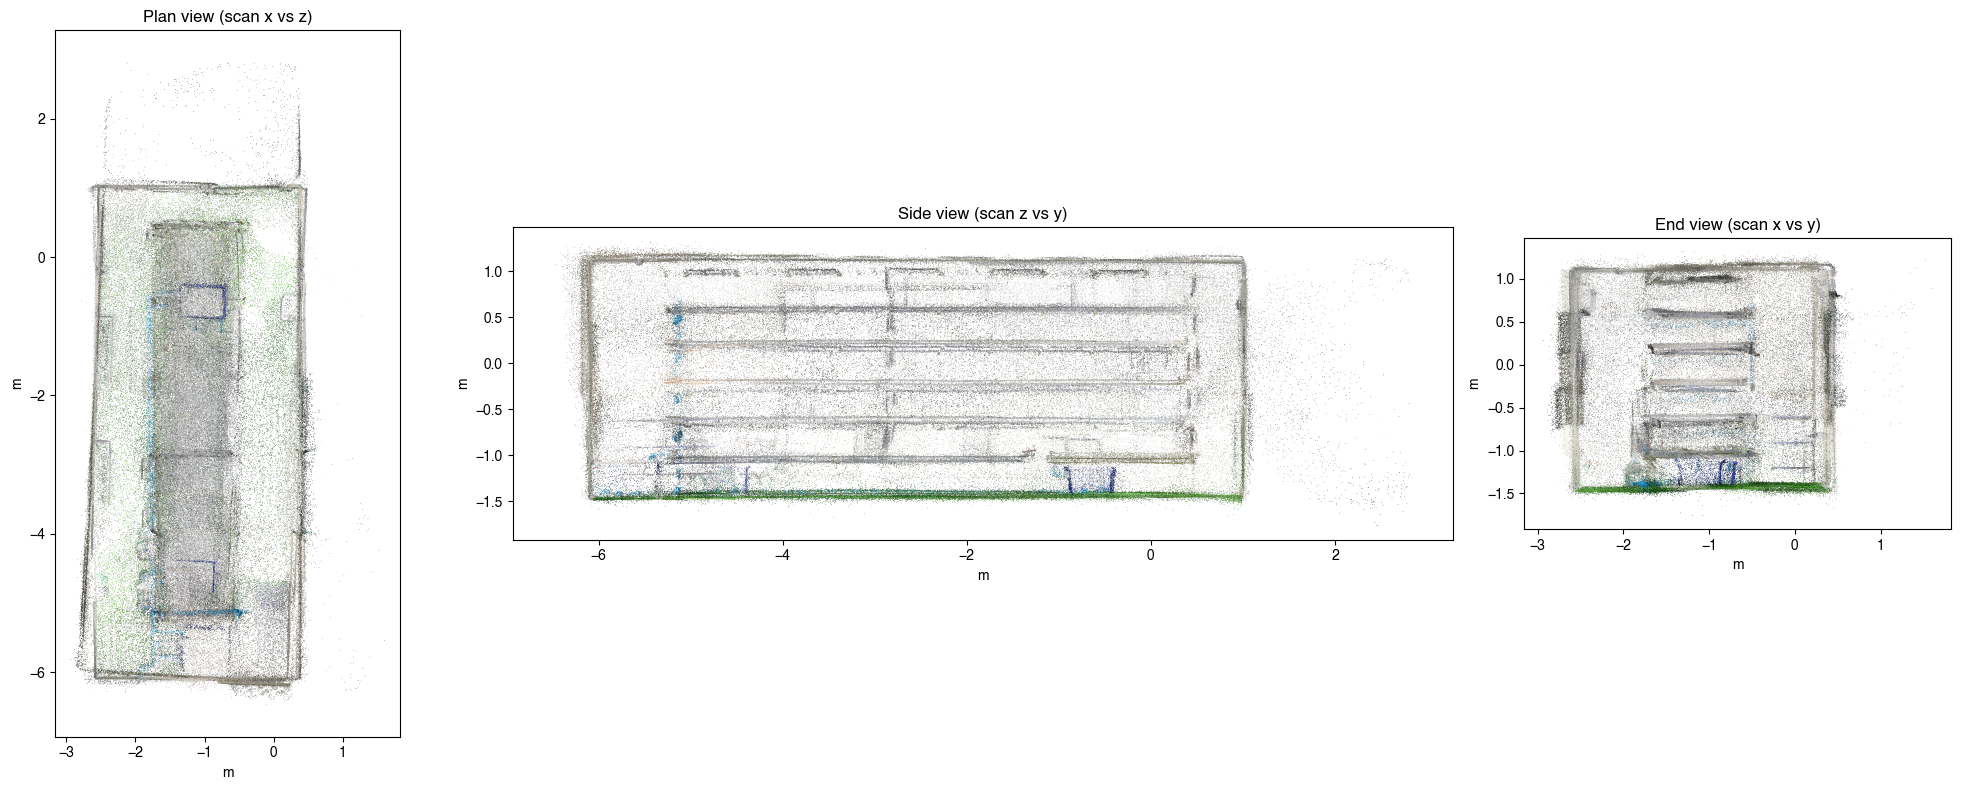

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(20, 8), gridspec_kw=dict(width_ratios=[1, 2.2, 1]))
viz.plan_view(xyz, rgb, ax=axes[0], xy=(0, 2), title="Plan view (scan x vs z)")
viz.plan_view(xyz, rgb, ax=axes[1], xy=(2, 1), title="Side view (scan z vs y)")
viz.plan_view(xyz, rgb, ax=axes[2], xy=(0, 1), title="End view (scan x vs y)")
for a in axes: a.set_xlabel("m"); a.set_ylabel("m")
fig.tight_layout(); fig.savefig(FIG / "01_views.png", dpi=130)

สังเกต: ห้องเอียงจากแกนเล็กน้อย (~2°), มีชั้นปลูก 1 แถวกลางห้อง ทางเดินสองข้าง, พื้นสีเขียว
จุดที่กระจายอยู่นอกกรอบด้านบนของ plan view คือส่วนที่สแกนเลยประตูออกไป

## 5. ตัดขวางตามความสูง (horizontal slabs) — ช่วยดูว่าแต่ละระดับมีอะไร

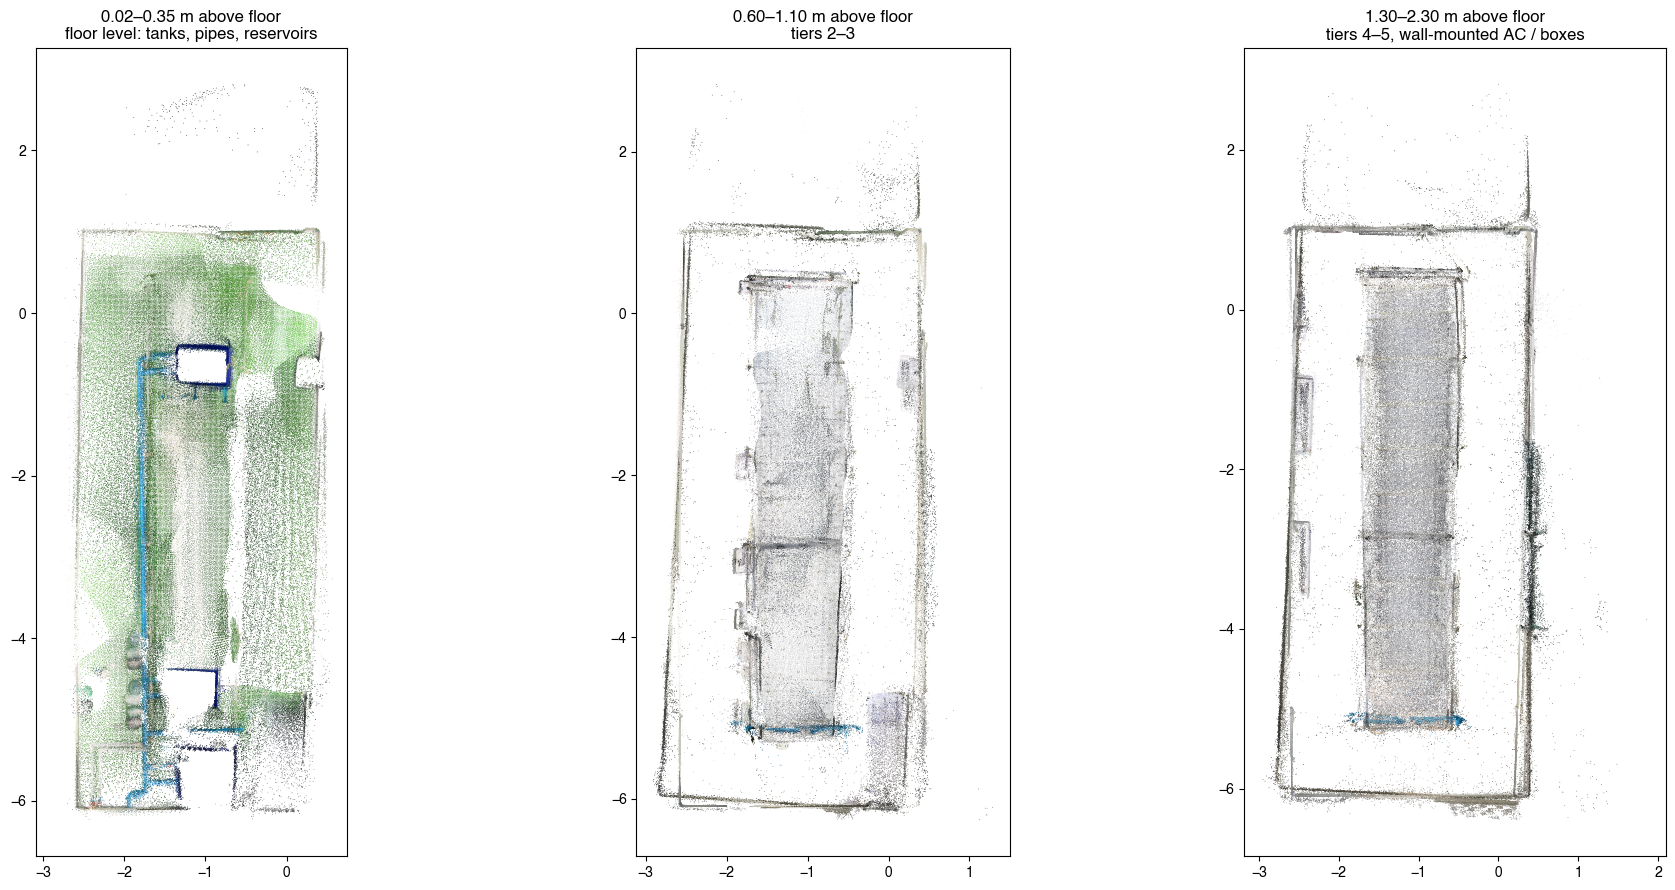

In [6]:
floor_y = np.percentile(xyz[horiz, 1], 1)
slabs = [(0.02, 0.35, "floor level: tanks, pipes, reservoirs"),
         (0.60, 1.10, "tiers 2–3"), (1.30, 2.30, "tiers 4–5, wall-mounted AC / boxes")]
fig, axes = plt.subplots(1, 3, figsize=(20, 9))
for ax, (lo, hi, name) in zip(axes, slabs):
    m = (xyz[:, 1] - floor_y > lo) & (xyz[:, 1] - floor_y < hi)
    viz.plan_view(xyz[m], rgb[m], ax=ax, xy=(0, 2), n=250000, s=0.3,
                  title=f"{lo:.2f}–{hi:.2f} m above floor\n{name}")
fig.tight_layout(); fig.savefig(FIG / "01_slabs.png", dpi=130)

## 6. ภาพ 3 มิติแบบโต้ตอบ (สุ่ม 80k จุดเพื่อความลื่น — ลาก/หมุน/ซูมได้; ปุ่ม **Full screen** เหนือรูป หรือเปิดไฟล์ `figures/html/*.html` ในเบราว์เซอร์เพื่อดูเต็มจอ)

In [7]:
fig3d = viz.figure_3d([viz.points_trace(xyz, rgb, n=80000, size=1.5)],
                      title="SIS-KU PFAL — raw LiDAR point cloud (scan frame, Y up)")
fig3d.update_layout(scene=dict(xaxis_title="x (m)", yaxis_title="y (m, up)", zaxis_title="z (m)"))
viz.show3d(fig3d, "01_raw_pointcloud")

full-window version: /Users/gasza/Documents/Job/SIS KU/Task/Rong_Pralong/PFAL/figures/html/01_raw_pointcloud.html   (open in a browser)


PosixPath('/Users/gasza/Documents/Job/SIS KU/Task/Rong_Pralong/PFAL/figures/html/01_raw_pointcloud.html')

## 7. คุณภาพข้อมูล: ความยาว normal, การกระจายสี

In [8]:
nlen = np.linalg.norm(normals, axis=1)
print(f"normal length: mean={nlen.mean():.4f}  min={nlen.min():.3f}  max={nlen.max():.3f}  (should be ~1)")
print("mean RGB:", rgb.mean(0).round(1), " | fraction of near-black points:", np.mean(rgb.mean(1) < 40).round(4))
# nearest-neighbour spacing on a random subset = effective point density
from scipy.spatial import cKDTree
idx = viz.subsample(len(xyz), 50000)
d, _ = cKDTree(xyz).query(xyz[idx], k=2)
print(f"median nearest-neighbour spacing: {np.median(d[:,1])*100:.1f} cm  (p90 {np.percentile(d[:,1],90)*100:.1f} cm)")

normal length: mean=1.0000  min=1.000  max=1.000  (should be ~1)
mean RGB: [143.1 149.7 139. ]  | fraction of near-black points: 0.0399


median nearest-neighbour spacing: 1.2 cm  (p90 2.0 cm)


## สรุปจาก Notebook 01
- 1.02 ล้านจุด, มี normal และสีครบ, ระยะห่างจุดระดับ ~1–3 ซม. → พอสำหรับ layout ระดับห้อง/ชั้นปลูก แต่ไม่พอสำหรับวัตถุเล็ก (เซ็นเซอร์, กล่องควบคุมเล็ก)
- ห้อง ~7.2 × 3.2 × 2.6 ม., ชั้นปลูก 5 ชั้นกลางห้อง
- ต้องแก้ใน Notebook 02: หมุนให้ผนังขนานแกน, ย้ายจุดกำเนิดไปมุมห้อง, แปลงเป็น Z-up, crop จุดนอกห้อง